# clustering

The optimal number of clusters was determined using the training set via elbow and silhouette analysis. Cluster stability was subsequently evaluated on the test set. Finally, the clustering model was refit on the full dataset to derive the final interpretable user segments.

In [38]:
# basic modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# train test split
from sklearn.model_selection import train_test_split

# preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# linear regression
from sklearn.linear_model import LinearRegression

# cluster
from sklearn.cluster import KMeans
import hdbscan

# metrics
from sklearn.metrics import silhouette_score
from sklearn.metrics import r2_score

# graphics
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
# read data

df = pd.read_pickle("C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features.pkl")


In [4]:
# check NaNs
# df.isna().sum() --- n=1245 NaNs in first_prompt, first_response

df = df[
    (df["first_prompt"] != "") &
    (df["first_response"] != "")
]

# probably: broken conversations, unpaired chats, incomplete samples; drop 1245 empty conversations

In [10]:
# orthographic rate error rate for cleaner text

#df[df["orthographic_error_rate"]>0.57] # n=53
df=df[df["orthographic_error_rate"]<=0.58]
df.shape


(53782, 25)

### train test split

In [11]:
# define targets and features
target = df["efficiency"]
features = df.drop(columns=["efficiency"])

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.20, random_state=42)

In [12]:
df.dtypes

conversation_id                          str
first_prompt                             str
first_response                           str
first_prompt_tokens                    int64
first_response_tokens                  int64
total_turns                            int64
interaction_rounds                   float64
total_user_tokens                      int64
total_assistant_tokens                 int64
total_tokens                           int64
log_total_tokens                     float64
follow_up_prompts                      int64
needs_follow_up                        int64
has_role_instruction                   int64
has_audience_or_level_instruction      int64
has_format_instruction                 int64
question_count                         int64
prompt_style                             str
task_type                                str
orthographic_error_rate              float64
topic_id                               int64
topic_label                              str
quality   

In [13]:
df["task_type"] = df["task_type"].astype("category")
df["prompt_style"] = df["prompt_style"].astype("category")
df["topic_label"] = df["topic_label"].astype("category")

In [14]:
# features selection for KMeans
  
FEATURES_SELECTED_v01 = {
    'cat': [
        "task_type",
        "topic_label",
        "prompt_style"        
        ],
    'num': [
        "first_prompt_tokens",
        "log_total_tokens",         # instead total_tokens, total_user_tokens
        "total_turns",                     # no interaction_rounds
        "orthographic_error_rate",
        "question_count",
        "needs_follow_up",
        ],
    'bin': [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
        "long_context_prompt"]
}

                         first_prompt_tokens  log_total_tokens  total_turns  \
first_prompt_tokens                     1.00              0.13         0.01   
log_total_tokens                        0.13              1.00         0.56   
total_turns                             0.01              0.56         1.00   
orthographic_error_rate                -0.05              0.07        -0.01   
question_count                          0.40              0.05         0.01   
needs_follow_up                         0.01              0.59         0.27   

                         orthographic_error_rate  question_count  \
first_prompt_tokens                        -0.05            0.40   
log_total_tokens                            0.07            0.05   
total_turns                                -0.01            0.01   
orthographic_error_rate                     1.00           -0.02   
question_count                             -0.02            1.00   
needs_follow_up                       

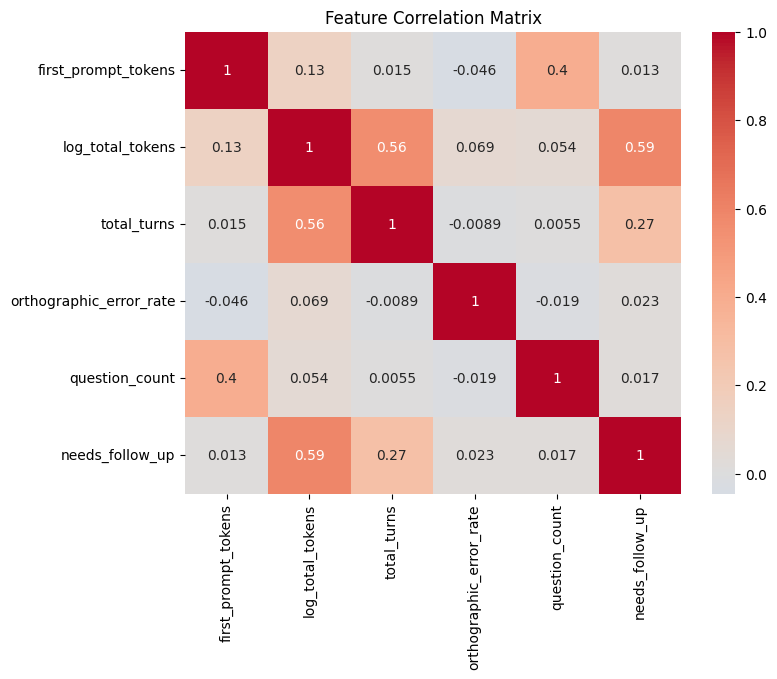

In [31]:
num_features = FEATURES_SELECTED_v01["num"]

corr = features[num_features].corr()

print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [16]:
# preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), FEATURES_SELECTED_v01["num"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v01["cat"]),
        ("bin", "passthrough", FEATURES_SELECTED_v01["bin"])
    ]
)


features_train_std = preprocessor.fit_transform(features_train)


inertias = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    labels = kmeans.fit_predict(features_train_std)

    inertias.append(kmeans.inertia_)

    sil_score = silhouette_score(
        features_train_std,
        labels,
        metric="euclidean"
    )

    silhouette_scores.append(sil_score)

    print(f"k={k}")
    print(f"  Inertia: {kmeans.inertia_:.2f}")
    print(f"  Silhouette: {sil_score:.4f}")

k=2
  Inertia: 299108.62
  Silhouette: 0.2339
k=3
  Inertia: 276146.19
  Silhouette: 0.2137
k=4
  Inertia: 270849.96
  Silhouette: 0.1571
k=5
  Inertia: 245854.94
  Silhouette: 0.1982
k=6
  Inertia: 230219.30
  Silhouette: 0.1748
k=7
  Inertia: 198224.36
  Silhouette: 0.1507
k=8
  Inertia: 177689.73
  Silhouette: 0.1812
k=9
  Inertia: 169958.08
  Silhouette: 0.1616
k=10
  Inertia: 164744.71
  Silhouette: 0.1334


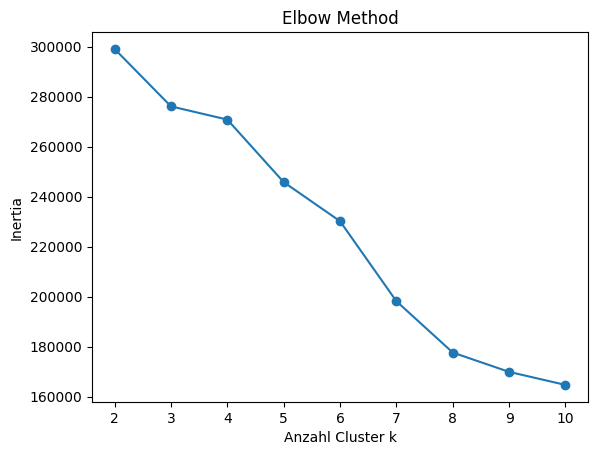

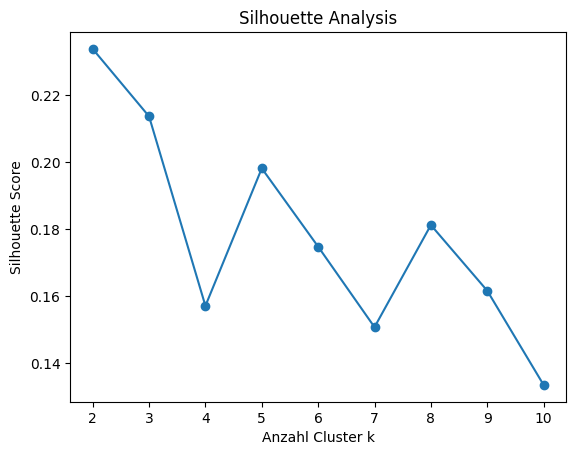

In [17]:
# elbow
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# silhouette
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [24]:
# preprocessing

model_KMeans = KMeans(n_clusters=5)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe, FEATURES_SELECTED_v01['cat']),
    ('num', num_pipe, FEATURES_SELECTED_v01['num']),
    ('bin', 'passthrough', FEATURES_SELECTED_v01['bin'])
])


# model

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model_KMeans)
])

In [25]:
# fit model and predict

pipeline.fit(features_train)

train_clusters = pipeline.predict(features_train)
test_clusters = pipeline.predict(features_test)

df.loc[features_train.index, "user_cluster"] = train_clusters
df.loc[features_test.index, "user_cluster"] = test_clusters

In [26]:
cluster_profile = (
    df.groupby("user_cluster")
    .agg(
        cluster_size=("user_cluster", "size"),
        total_tokens_sum=("total_tokens", "sum"),
        total_tokens_mean=("total_tokens", "mean"),
        total_turns=("total_turns", "mean"),
        interaction_rounds=("interaction_rounds", "mean"),
        question_count=("question_count", "mean"),
        orthographic_error_rate=("orthographic_error_rate", "mean"),
        quality_score=("quality", "mean"),
        has_role_instruction=("has_role_instruction", "mean"),
        has_format_instruction=("has_format_instruction", "mean"),
        has_long_context=("long_context_prompt", "mean")
    )
    .round(2)
)

cluster_profile

,cluster_size,total_tokens_sum,total_tokens_mean,total_turns,interaction_rounds,question_count,orthographic_error_rate,quality_score,has_role_instruction,has_format_instruction,has_long_context
user_cluster,,,,,,,,,,,
0.00,22137,42959995,1940.64,9.62,4.81,0.42,0.03,0.33,0.15,0.21,0.00
1.00,14742,10300393,698.71,1.92,0.96,0.45,0.04,0.33,0.09,0.21,0.01
2.00,10469,128801566,12303.14,37.10,18.55,1.12,0.04,0.30,0.18,0.37,0.05
3.00,6027,22792369,3781.71,11.48,5.74,0.39,0.21,0.38,0.01,0.14,0.00
4.00,407,29452711,72365.38,263.90,131.95,0.47,0.05,0.33,0.16,0.25,0.01


## task type and topic label

In [27]:
pd.crosstab(
    df["user_cluster"],
    df["task_type"],
    normalize="index"
)

task_type,brainstorming,coding,email_writing,explanation,general_assistance,roleplay,summarization,translation,writing_generation
user_cluster,,,,,,,,,
0.00,0.05,0.13,0.02,0.10,0.45,0.03,0.02,0.02,0.18
1.00,0.03,0.19,0.03,0.09,0.42,0.01,0.02,0.02,0.20
2.00,0.03,0.38,0.02,0.07,0.30,0.02,0.03,0.02,0.14
3.00,0.01,0.32,0.00,0.08,0.47,0.00,0.02,0.01,0.09
4.00,0.02,0.19,0.01,0.08,0.43,0.03,0.01,0.01,0.21


In [28]:
pd.crosstab(
    df["user_cluster"],
    df["topic_label"],
    normalize="index"
)

topic_label,casual_chat_or_games,coding,creative_writing,explanation,general_business_assistance,jailbreak_roleplay,prompting_or_questions,web_search_or_url_task
user_cluster,,,,,,,,
0.00,0.03,0.13,0.12,0.04,0.53,0.02,0.08,0.03
1.00,0.02,0.16,0.15,0.04,0.48,0.01,0.08,0.06
2.00,0.03,0.31,0.09,0.03,0.40,0.03,0.08,0.04
3.00,0.03,0.42,0.08,0.03,0.22,0.02,0.06,0.14
4.00,0.03,0.18,0.09,0.03,0.46,0.05,0.13,0.03


### check with regression: How strongly do the other features predict total_tokens?

In [29]:
# preprocessing

model_reg = LinearRegression()

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe, FEATURES_SELECTED_v01['cat']),
    ('num', num_pipe, FEATURES_SELECTED_v01['num']),
    ('bin', 'passthrough', FEATURES_SELECTED_v01['bin'])
])


# pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model_reg)
])

# model

pipeline.fit(features_train, target_train)

target_test_pred = pipeline.predict(features_test)

print(r2_score(target_test, target_test_pred))

0.5879727280665834


## Insights

### 4 Engagement-Level Clusters

Although k=5 achieved a slightly higher silhouette score, the fifth cluster consisted of only six extreme outlier observations. Therefore, k=4 was selected as the preferred clustering solution due to its superior interpretability, stability, and more balanced cluster structure.

| Cluster | Label                           |
| ------- | ------------------------------- |
| 0       | Engaged General Users           |
| 1       | Casual / One-shot Users         |
| 2       | Power / Technical Users         |
| 3       | Outlier / Extreme Context Users |


 Power/Technical Users

- total_tokens:	15,903
- total_turns:	49
- coding:	36%
- coding topic	38%
- general assistance:	still high
- writing_generation:	existing

Maybe:
iterative Arbeit,
Coding,
Projektarbeit,
längere Sessions.

User clustering in deinem Dataset ist primarily driven by engagement intensity, not by topic or task semantics.

# HDBSCAN model

In [33]:
cat_features = [
    "task_type",
    "topic_label",
    "prompt_style"
]

num_features = [
    "first_prompt_tokens",
    "log_total_tokens",
    "total_turns",
    "orthographic_error_rate",
    "question_count",
    "needs_follow_up",
]

bin_features = [
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "long_context_prompt"
]

In [34]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("bin", "passthrough", bin_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop"
)

In [35]:
dim_reducer = PCA(n_components=10)

In [43]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,      # wichtig: je nach dataset anpassen
    min_samples=10,           # höher = mehr "noise"
    metric="euclidean",
    cluster_selection_method="eom"
)


pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("pca", dim_reducer),
    ("cluster", clusterer)
])


labels = pipeline.fit_predict(df)

df["cluster"] = labels


print(df["cluster"].value_counts())

noise_ratio = (df["cluster"] == -1).mean()
print("Noise ratio:", noise_ratio)

cluster_probs = pipeline.named_steps["cluster"].probabilities_
df["cluster_confidence"] = cluster_probs



cluster
-1     22608
 71     1974
 75     1815
 26     1796
 91     1647
       ...  
 1        59
 15       58
 48       53
 9        52
 63       52
Name: count, Length: 99, dtype: int64
Noise ratio: 0.42036369045405525


In [44]:
cluster_sizes = df["cluster"].value_counts()

small_clusters = cluster_sizes[cluster_sizes < 200].index

df["cluster_coarse"] = df["cluster"].apply(
    lambda x: -1 if x in small_clusters else x
)

In [47]:
df["cluster_coarse"].value_counts()

cluster_coarse
-1     28655
 71     1974
 75     1815
 26     1796
 91     1647
 86     1484
 77     1370
 60     1052
 69      924
 70      868
 14      706
 67      688
 62      572
 88      556
 18      537
 90      489
 74      463
 30      425
 13      416
 89      401
 85      399
 93      369
 92      356
 44      355
 95      348
 19      340
 16      327
 50      310
 65      309
 83      304
 61      303
 97      298
 39      298
 58      296
 20      289
 64      281
 43      275
 68      272
 41      247
 81      246
 11      242
 66      241
 42      239
Name: count, dtype: int64

In [48]:
large_clusters = df["cluster"].value_counts()
large_clusters = large_clusters[large_clusters > 1000].index

df["macro_cluster"] = df["cluster"].apply(
    lambda x: x if x in large_clusters else -1
)

In [49]:
df["macro_cluster"].value_counts()

macro_cluster
-1     42644
 71     1974
 75     1815
 26     1796
 91     1647
 86     1484
 77     1370
 60     1052
Name: count, dtype: int64

In [50]:
macro_cluster_profile = (
    df.groupby("macro_cluster")
    .agg(
        cluster_size=("user_cluster", "size"),
        total_tokens_sum=("total_tokens", "sum"),
        total_tokens_mean=("total_tokens", "mean"),
        total_turns=("total_turns", "mean"),
        interaction_rounds=("interaction_rounds", "mean"),
        question_count=("question_count", "mean"),
        orthographic_error_rate=("orthographic_error_rate", "mean"),
        quality_score=("quality", "mean"),
        has_role_instruction=("has_role_instruction", "mean"),
        has_format_instruction=("has_format_instruction", "mean"),
        has_long_context=("long_context_prompt", "mean")
    )
    .round(2)
)

macro_cluster_profile

,cluster_size,total_tokens_sum,total_tokens_mean,total_turns,interaction_rounds,question_count,orthographic_error_rate,quality_score,has_role_instruction,has_format_instruction,has_long_context
macro_cluster,,,,,,,,,,,
-1,42644,198881352,4663.76,15.99,7.99,0.67,0.06,0.32,0.13,0.26,0.01
26,1796,1774225,987.88,1.35,0.67,0.00,0.00,0.40,0.00,0.00,0.00
60,1052,5141678,4887.53,12.54,6.27,0.00,0.08,0.37,0.00,0.10,0.00
71,1974,12500123,6332.38,12.90,6.45,0.00,0.07,0.32,0.10,0.25,0.00
75,1815,4823186,2657.40,12.82,6.41,0.00,0.02,0.30,0.46,0.32,0.00
77,1370,3954047,2886.17,14.09,7.04,0.00,0.05,0.37,0.05,0.06,0.00
86,1484,2975686,2005.18,12.13,6.07,1.00,0.00,0.37,0.00,0.00,0.00
91,1647,4256737,2584.54,13.93,6.97,0.00,0.00,0.37,0.00,0.00,0.00


In [51]:
pd.crosstab(
    df["macro_cluster"],
    df["task_type"],
    normalize="index"
)

task_type,brainstorming,coding,email_writing,explanation,general_assistance,roleplay,summarization,translation,writing_generation
macro_cluster,,,,,,,,,
-1,0.03,0.23,0.02,0.10,0.35,0.01,0.02,0.02,0.21
26,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
60,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
71,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75,0.32,0.00,0.10,0.21,0.00,0.23,0.09,0.05,0.00
77,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
86,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
91,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
